# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
import numpy as np
import qiskit.quantum_info as qi
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

from qiskit_noise_learning.aer_executor import AerExecutor

backend = FakeFez()

## 1. Build a gate set with a single layer on a ring of qubits

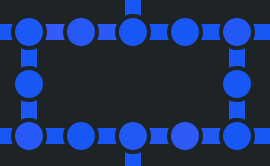

In [2]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [25, 26]  # [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26)]  # [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [3]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2)

# Neglecting SPAM for now:
pauli_lindblad_model.generators["M"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)
pauli_lindblad_model.generators["P"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)

pauli_lindblad_model.generators

{'M': <QubitSparsePauliList with 0 elements on 156 qubits: []>,
 'P': <QubitSparsePauliList with 0 elements on 156 qubits: []>,
 'layer_1': <QubitSparsePauliList with 15 elements on 156 qubits: [Z_25, X_25, Y_25, Z_26, X_26, Y_26, Z_26 Z_25, Z_26 X_25, Z_26 Y_25, X_26 Z_25, X_26 X_25, X_26 Y_25, Y_26 Z_25, Y_26 X_25, Y_26 Y_25]>}

## 3. Build learning experiments

In [88]:
from qiskit_noise_learning.experiment_builder import (
    BindSequenceDepths,
    CompleteSequences,
    EvenDepthPaths,
    Experiment,
    GenerateInstructionSequences,
    IdentifyRelations,
    MergeInstructionSequences,
    EvenDepthVanillaPaths,
    VanillaInstructionSequences,
    RankReducePaths,
)

# experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=20, randomizations=50)
experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=2**14, randomizations=1)  # 50)

experiment_builder = (
    # add paths
    #EvenDepthVanillaPaths()
    EvenDepthPaths()
    # + Depth1Paths()
    + RankReducePaths()
    # add instruction sequences measuring 9 bases
    #+ VanillaInstructionSequences()
    + GenerateInstructionSequences()
    + MergeInstructionSequences()
    # relate them to the paths, and complete them
    #+ IdentifyRelations()
    + CompleteSequences()
    # set numerical parameters
    # + BindSequenceDepths([0, 2, 16, 32, 64, 128])
    + BindSequenceDepths([1, 2, 4, 8, 16, 32])
)

experiment = experiment_builder.run(experiment)

print(f"Number of paths: {len(experiment.paths)}")
print(f"Number of instruction sequences: {len(experiment.instruction_sequences)}")
print(f"Rank: {experiment.design_matrix.rank} / {len(pauli_lindblad_model.generators['layer_1'])}")

Number of paths: 13
Number of instruction sequences: 48
Rank: 13 / 15


## 4. Run experiments

In [89]:
from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator

# # build post selection pass manager
# post_selection_pm = PassManager(
#     [
#         AddSpectatorMeasures(backend.coupling_map),
#         AddPostSelectionMeasures(x_pulse_type="rx"),
#     ]
# )

circuit_generator = ExecutorCircuitGenerator(gate_set)  # , pass_manager=post_selection_pm)
quantum_program, data_mapper = circuit_generator.generate(experiment)

print(f"Number of template circuits: {len(quantum_program.items)}")
# for item in quantum_program.items:
#    display(item.circuit.draw("mpl", idle_wires=False, fold=False))

Number of template circuits: 6


In [90]:
qasm_simulator = AerSimulator(
    coupling_map=backend.coupling_map,
    seed_simulator=111,
    method="stabilizer",
)

num_qubits = gate_set.get("layer_1").num_qubits
# plm1 = qi.PauliList.from_symplectic(z=np.eye(num_qubits),x=np.zeros((num_qubits,num_qubits)))
# plm1 = qi.PauliLindbladMap.from_list([(z.to_label(),(i+1)*1e-3) for i,z in enumerate(plm1)])
two_locals = qi.pauli_basis(2)[1:]
identity = qi.Pauli("I" * num_qubits)
generators = qi.PauliList.from_symplectic(
    z=np.empty(shape=(0, num_qubits)), x=np.empty(shape=(0, num_qubits))
)
identities = qi.PauliList(["I" * num_qubits] * len(two_locals))
for qubit in range(num_qubits):
    # assuming ordered ring of qubits (?)
    generators += identities.compose(two_locals, qargs=(qubit, (qubit + 1) % num_qubits))
generators = generators.unique().to_labels()
plm1 = qi.PauliLindbladMap.from_list(
    list(
        zip(
            generators,
            #  1e-2*np.random.random(len(generators))
            np.linspace(0, 1e-2, len(generators)),
        )
    ),
    num_qubits=num_qubits,
)
# too hard:
plm1 = plm1[::5]
del generators

num_qubits = gate_set.get("M").num_qubits
plm_meas = qi.PauliLindbladMap.from_list([], num_qubits=num_qubits)

num_qubits = gate_set.get("P").num_qubits
plm_prep = qi.PauliLindbladMap.from_list([], num_qubits=num_qubits)

executor = AerExecutor(
    qasm_simulator=qasm_simulator,
    noise_dict={"layer_1": plm1, "M": plm_meas, "P": plm_prep},
    angle_decimals=3,
)

In [91]:
plm1

<PauliLindbladMap with 3 terms on 2 qubits: (0)L(X_0) + (0.0035714285714285713)L(X_1 Y_0) + (0.007142857142857143)L(Y_1 Z_0)>

In [92]:
# run program and provide initial population of fit
job = executor.run(quantum_program)
fit = circuit_generator.collect(job.result(), data_mapper)

## 5. Analyzing the data

In [93]:
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    # FlipPostSelect,
    NNLSSolve,
)

# analyzer = FlipPostSelect() + ComputeObservables() + CurveFitObservables() + NNLSSolve()
analyzer = ComputeObservables() + CurveFitObservables() + NNLSSolve()
# analyzer = ComputeObservables() + CurveFitObservables() + LSQLinearSolve()

In [94]:
fit = analyzer.run(fit)

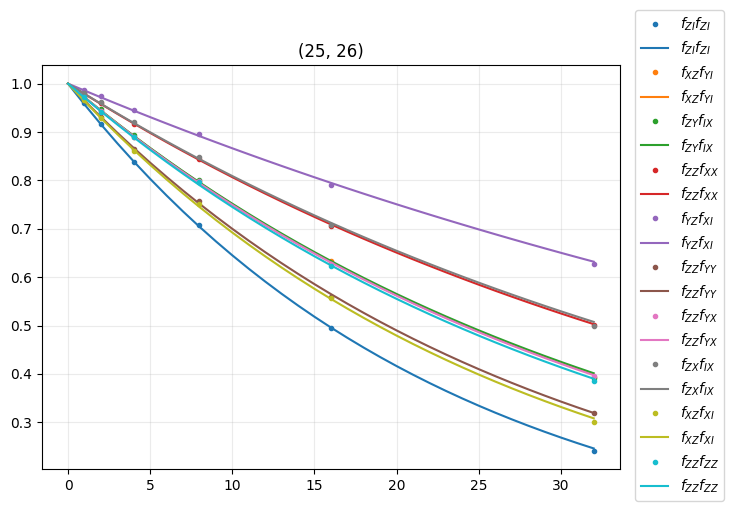

In [95]:
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

from qiskit_noise_learning.analysis import AverageObservables

# compute observables and plot empirical decays

averaged_data = AverageObservables().run(fit).averaged_data

def _sorted_decays(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for unbound_path, depth, val in zip(
        dataset["unbound_path"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth >= 0:
            continue
        sorted_data[unbound_path] = val

    return sorted_data


def _sorted_data(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for unbound_path, depth, val in zip(
        dataset["unbound_path"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth < 0:
            continue
        this_data = sorted_data.setdefault(unbound_path, ([], []))
        this_data[0].append(val)
        this_data[1].append(depth)

    return {k: v for k, v in sorted_data.items() if len(v[0]) > 1}  # filter on decays

def fidelity_label(unbound_path, subset):
    return (
        "$f_{"
        + "} f_{".join(
            "".join(str(fid.pauli.to_pauli()[subset])) for fid in unbound_path.repeatable_fragment
        )
        + "} $"
    )

def plot_with_exp_decay(
    decay_data, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)
    sorted_decays = _sorted_decays(decay_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    from matplotlib.pyplot import Axes

    axes_iter = [axs] if isinstance(axs, Axes) else axs.flat

    for ax, (subset, unbound_paths) in zip(axes_iter, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(unbound_paths)
        for color_code, unbound_path in list(zip(mcolors.TABLEAU_COLORS.values(), unbound_paths))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            fid_est = sorted_decays[unbound_path]
            ax.plot(
                np.arange(1 + max(this_data[1])),
                fid_est ** (np.arange(1 + max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        ax.grid(alpha=0.25)
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


plot_with_exp_decay(
    fit.averaged_data, averaged_data, layer_1_pairs, num_cols=1
)


In [98]:
model_data = fit.model_data
noise_maps = pauli_lindblad_model.to_pauli_lindblad_maps(model_data)
noise_maps = {k:v.simplify() for k,v in noise_maps.items()}

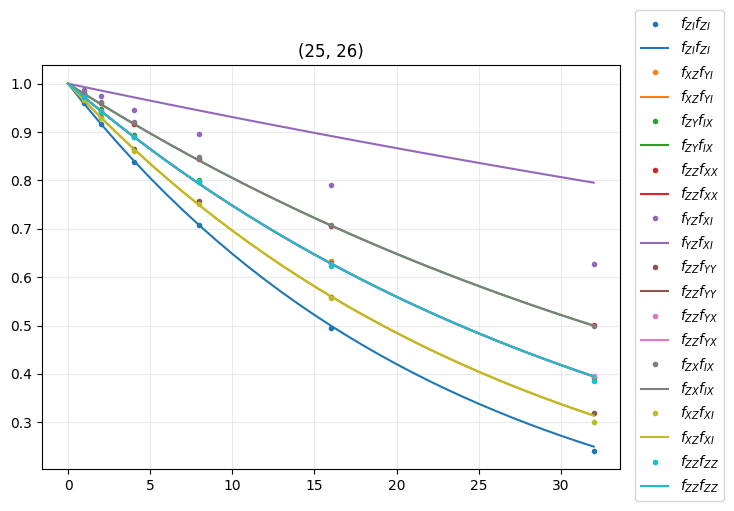

In [99]:
# plot decays v.s. model prediction
# Note: plotting model decays without prefactors from SPAM
import matplotlib.colors as mcolors
import numpy as np


def plot_with_model_decay(
    pauli_lindblad_map, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    from matplotlib.pyplot import Axes

    axes_iter = [axs] if isinstance(axs, Axes) else axs.flat

    for ax, (subset, unbound_paths) in zip(axes_iter, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(unbound_paths)
        for color_code, unbound_path in list(zip(mcolors.TABLEAU_COLORS.values(), unbound_paths))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            pauli_in = unbound_path.repeatable_fragment[0].transition[0]
            fidelity_in = pauli_lindblad_map.pauli_fidelity(pauli_in)
            pauli_out = unbound_path.repeatable_fragment[0].transition[1]
            fidelity_out = pauli_lindblad_map.pauli_fidelity(pauli_out)
            ax.plot(
                np.arange(1 + max(this_data[1])),
                (fidelity_in * fidelity_out) ** (np.arange(1 + max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        ax.grid(alpha=0.25)
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


# k = 8
plot_with_model_decay(
    noise_maps["layer_1"], averaged_data, layer_1_pairs, num_cols=1
)  # , start_idx=k, end_idx=k + 1)

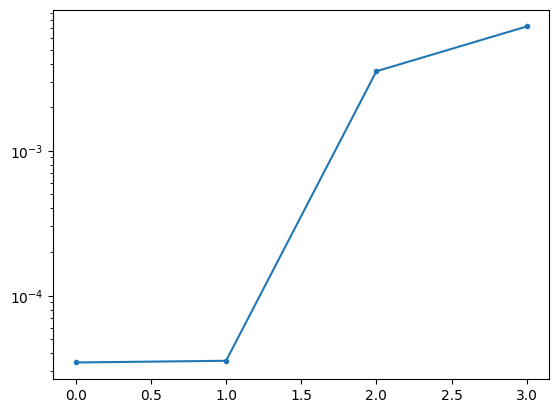

In [97]:
generators = noise_maps["layer_1"].generators
rates = noise_maps["layer_1"].rates

plt.semilogy(np.sort(rates), marker=".")

## 7. Investigating results

[Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...'), Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...')]
[Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...'), Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...'), Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...'), Pauli('IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...')]


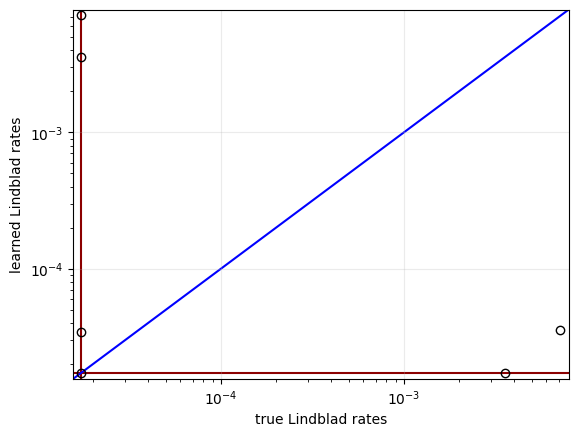

In [30]:
learned_model = noise_maps["layer_1"]

true_model_phys = plm1.apply_layout(
    layout=gate_set["layer_1"].qubit_idxs, num_qubits=learned_model.num_qubits
)

learned_vs_true = []
true_model_lookup = {
    g: r for g, r in zip(true_model_phys.generators().to_pauli_list(), true_model_phys.rates)
}
learned_model_lookup = {
    g: r for g, r in zip(learned_model.generators().to_pauli_list(), learned_model.rates)
}
generators = list(set(true_model_lookup.keys()) | set(learned_model_lookup.keys()))
true_gens_active = []
learned_gens_active = []
for g in generators:
    true = true_model_lookup.get(g, 0)
    learned = learned_model_lookup.get(g, 0)
    if true != 0:
        true_gens_active.append(g)
    if learned != 0:
        learned_gens_active.append(g)
    learned_vs_true.append((true, learned))
learned_vs_true = np.transpose(learned_vs_true)

print(true_gens_active)
print(learned_gens_active)
epsilon = min(learned_vs_true[learned_vs_true > 0]) / 2.0
learned_vs_true[learned_vs_true == 0] = epsilon
lims = (np.min(learned_vs_true) * 0.9, np.max(learned_vs_true) * 1.1)
plt.loglog(learned_vs_true[0], learned_vs_true[1], ls="", marker="o", color="black", mfc="none")
plt.axvline(epsilon, color="darkred", zorder=-1)
plt.axhline(epsilon, color="darkred", zorder=-1)
plt.plot(lims, lims, color="blue", zorder=-1)
plt.ylim(lims)
plt.xlim(lims)
plt.xlabel("true Lindblad rates")
plt.ylabel("learned Lindblad rates")
plt.grid(alpha=0.25)
plt.show()

In [31]:
print("false positives:")
count = 0
onenorm = 0
for g in learned_gens_active:
    if g not in true_gens_active:
        print(qi.QubitSparsePauli(g), learned_model_lookup[g])
        count += 1
        onenorm += learned_model_lookup[g]
print(f"{count} terms with 1-norm {onenorm}")

false positives:
<QubitSparsePauli on 156 qubits: Y_26 Y_25> 3.4461279937418055e-05
<QubitSparsePauli on 156 qubits: Y_26 X_25> 0.003543093289782678
<QubitSparsePauli on 156 qubits: Y_26> 0.007225644163406506
3 terms with 1-norm 0.010803198733126603


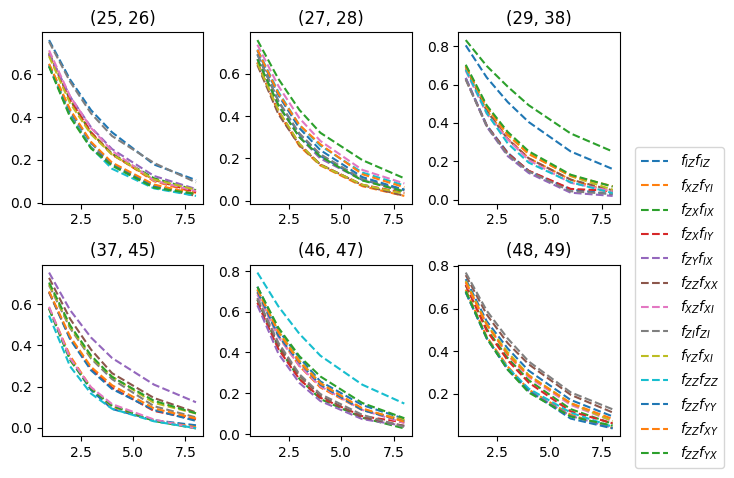

In [194]:
from matplotlib import pyplot as plt

from qiskit_noise_learning.analysis import AverageObservables

# compute observables and plot empirical decays

averaged_data = AverageObservables().run(fit).averaged_data


def _sorted_data(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for unbound_path, depth, val in zip(
        dataset["unbound_path"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth < 0:
            continue
        this_data = sorted_data.setdefault(unbound_path, ([], []))
        this_data[0].append(val)
        this_data[1].append(depth)

    return {k: v for k, v in sorted_data.items() if len(v[0]) > 1}  # filter on decays


def plot(averaged_data, subsets, num_cols=3):
    sorted_data = _sorted_data(averaged_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, unbound_paths) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        for unbound_path in unbound_paths:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                "--",
                label=label,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


def fidelity_label(unbound_path, subset):
    return (
        "$f_{"
        + "} f_{".join(
            "".join(str(fid.pauli.to_pauli()[subset])) for fid in unbound_path.repeatable_fragment
        )
        + "} $"
    )


plot(averaged_data, layer_1_pairs)

In [195]:
model_data = fit.model_data
noise_maps = pauli_lindblad_model.to_pauli_lindblad_maps(model_data)

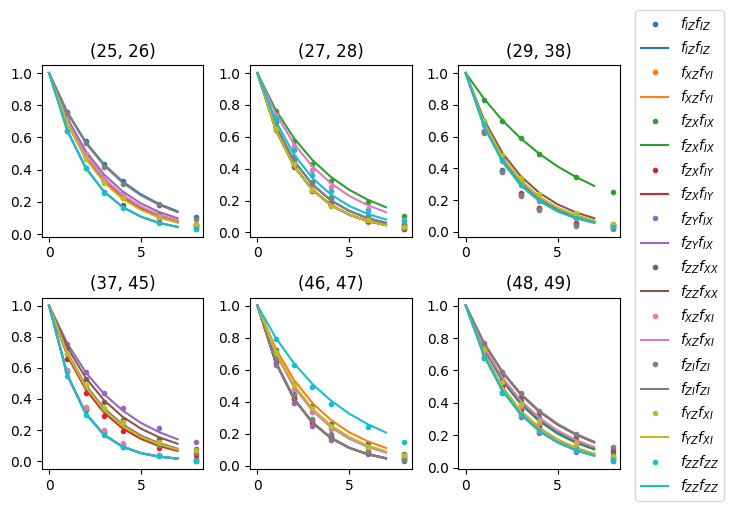

In [196]:
# plot decays v.s. model prediction
# Note: plotting model decays without prefactors from SPAM
import numpy as np


def plot_with_model_decay(
    pauli_lindblad_map, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for unbound_path in sorted_data.keys():
            if set(subset).issuperset(unbound_path.start_fragment[0].out_bit_indices):
                plots[subset].append(unbound_path)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, unbound_paths) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(unbound_paths)
        for color_code, unbound_path in list(zip(mcolors.TABLEAU_COLORS.values(), unbound_paths))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[unbound_path]
            label = fidelity_label(unbound_path, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            pauli_in = unbound_path.repeatable_fragment[0].transition[0]
            fidelity_in = pauli_lindblad_map.pauli_fidelity(pauli_in)
            pauli_out = unbound_path.repeatable_fragment[0].transition[1]
            fidelity_out = pauli_lindblad_map.pauli_fidelity(pauli_out)
            ax.plot(
                np.arange(max(this_data[1])),
                (fidelity_in * fidelity_out) ** (np.arange(max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


# k = 8
plot_with_model_decay(
    noise_maps["layer_1"], averaged_data, layer_1_pairs
)  # , start_idx=k, end_idx=k + 1)